# Smartphones in India, 2023
## Task 4 · Supervised machine learning with decision trees

**T4EU Data Science Winter School, Katowice** · Team: Oleksandr Klepachevskyi, Sakthi Sivaram Manikandan

In Task 2 we saw that flagships cost more than twice as much as Premium phones, and in Task 3 that the specs explain most of a phone's price. Now we ask the question as a **classification** problem:

> **Can a decision tree tell a phone's price segment (Budget, Mid-range, Premium or Flagship) from its specs alone? And which specs decide it?**

A decision tree is a good tool for this, because it doesn't only predict: it shows its reasoning as simple yes/no questions, like "Is the RAM more than 5 GB?".

**How we cover the tasks**

| Task | Where |
|---|---|
| 1. Select the dataset | Part 1 |
| 2. Data preparation | Part 2 |
| 3. Splitting the dataset | Part 3 |
| 4. A decision tree as a classifier | Part 4 |
| 4a. Trees of different depths, the best depth | 4a |
| 4b. Different numbers of phones in a leaf, the best number | 4b |
| 5. Classification metrics and model characteristics | Part 5 |
| 5a. Visualizations | charts in Parts 4 and 5 (the tree itself in 5.3) |
| 6. Optional: decision rules, and rules vs tree | Part 6 |

In [1]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import PercentFormatter
from pathlib import Path

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.3f}".format)

DATA = Path("data")
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

# We use the same chart style as in Tasks 1-3 (colour-blind-safe colours)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
SEGMENTS = ["Budget", "Mid-range", "Premium", "Flagship"]
SEGMENT_COLORS = ["#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]      # Budget -> Flagship, light to dark (as in Task 2)
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 2, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
    "legend.frameon": False, "figure.dpi": 110, "savefig.dpi": 160,
})

def save(fig, name):
    # We save every chart to figures/ so it can go straight into our slides
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")

df = pd.read_csv(DATA / "smartphones_clean.csv")
print(f"Clean data from Task 1: {df.shape[0]} phones x {df.shape[1]} columns")

Clean data from Task 1: 907 phones x 61 columns


## Part 1 · Our dataset and what we classify
We use our clean dataset from Task 1: **907 real smartphones** listed in 2023 on Smartprix, an Indian price-comparison website.

**The class we predict** is the **price segment** that we created in Task 1:

| Segment | Price |
|---|---|
| Budget | below ₹15,000 (about €167) |
| Mid-range | ₹15,000–29,999 |
| Premium | ₹30,000–59,999 |
| Flagship | ₹60,000 or more (about €667) |

In [2]:
counts = df["price_segment"].value_counts().reindex(SEGMENTS)
pd.DataFrame({"phones": counts, "share": (counts / len(df)).map("{:.1%}".format)})

,phones,share
price_segment,,
Budget,326,35.9%
Mid-range,324,35.7%
Premium,154,17.0%
Flagship,103,11.4%


The segments are not equally big: Budget and Mid-range have about 36% of the phones each, Premium 17% and Flagship only 11%. So a model that always answers "Budget" would already be right 35.9% of the time: this is the **baseline** that our tree must beat. Because the classes are unbalanced, we will also look at the results for each segment, not only at the overall accuracy.

## Part 2 · Data preparation
Most of the preparation was already done in Task 1: there are no missing values, the yes/no columns are 1/0, and the chip families are one-hot encoded. For the decision tree we only need to choose the **features** (the questions the tree may ask):

- **We use 27 specs:** processor speed, RAM, storage, battery, fast charging, screen size, refresh rate, the cameras, pixel density, 5G, NFC, IR blaster, memory-card slot, iPhone (iOS), foldable, and the chip family (10 one-hot columns).
- **We leave out everything that contains the price**, because the tree would simply read the answer from it: `price`, `price_eur`, `log_price`, `price_z` and `is_outlier` (which is based on the price).
- **We leave out the rating**, for the same reason as in Task 3: in Task 1 we filled its missing values from the price group.
- **We don't need the z-scores from Task 1.** A tree only compares one variable at a time with a threshold, so the units don't matter.

The tree needs numbers, so we code the four segments as 0 = Budget, 1 = Mid-range, 2 = Premium, 3 = Flagship. The numbers are only labels: the tree treats them as four separate classes.

In [3]:
df["is_foldable"] = (df["is_foldable"] == "Yes").astype(int)          # Yes/No -> 1/0

# The features and the readable names we use in charts and rules
NAMES = {
    "processor_speed": "processor speed (GHz)", "ram_capacity": "RAM (GB)", "internal_memory": "storage (GB)",
    "battery_capacity": "battery (mAh)", "fast_charging": "fast charging (W)", "screen_size": "screen size (inches)",
    "refresh_rate": "refresh rate (Hz)", "primary_camera_rear": "main camera (MP)", "primary_camera_front": "front camera (MP)",
    "num_rear_cameras": "rear cameras", "ppi": "pixel density (ppi)", "has_5g": "5G", "has_nfc": "NFC",
    "has_ir_blaster": "IR blaster", "extended_memory_available": "memory-card slot", "os_ios": "iPhone (iOS)",
    "is_foldable": "foldable", "chip_bionic": "Apple Bionic chip", "chip_dimensity": "MediaTek Dimensity chip",
    "chip_exynos": "Samsung Exynos chip", "chip_google": "Google Tensor chip", "chip_helio": "MediaTek Helio chip",
    "chip_kirin": "Huawei Kirin chip", "chip_mediatek": "other MediaTek chip", "chip_snapdragon": "Snapdragon chip",
    "chip_unisoc": "Unisoc chip", "chip_unknown": "unknown chip"}
features = list(NAMES)

X = df[features]
y = df["price_segment"].map({segment: i for i, segment in enumerate(SEGMENTS)})          # 0 = Budget ... 3 = Flagship
print(f"X: {X.shape[0]} phones x {X.shape[1]} features | missing values: {int(X.isna().sum().sum())}")
X.describe().T[["mean", "min", "max"]]

X: 907 phones x 27 features | missing values: 0


,mean,min,max
processor_speed,2.424,1.200,3.220
ram_capacity,6.502,1.000,18.000
internal_memory,139.669,8.000,"1,024.000"
battery_capacity,"4,809.695","1,821.000","22,000.000"
fast_charging,36.996,0.000,240.000
screen_size,6.539,3.540,8.030
refresh_rate,91.743,60.000,240.000
primary_camera_rear,49.129,2.000,200.000
primary_camera_front,16.293,0.300,60.000
num_rear_cameras,2.806,1.000,4.000


## Part 3 · Splitting the dataset
We split the data in two steps:

1. **Training set and test set (80% / 20%).** We build and tune our trees only on the training set. The test set stays locked away until the very end, so it shows how well our final tree works on phones it has never seen. The split is **stratified**: each segment has the same share in both sets (the Flagship segment is small, so a random split could leave too few flagships in the test set).
2. **Cross-validation on the training set.** To compare trees (Parts 4a and 4b) we don't use the test set. Instead we use **5-fold cross-validation**: we cut the training set into 5 parts, train on 4 and test on the 5th, five times. Because 5 folds are still a bit random, we **repeat this 5 times** with different random cuts and average all **25 scores**.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

shares = pd.DataFrame({name: part.value_counts(normalize=True).sort_index().values
                       for name, part in [("all phones", y), ("training set", y_train), ("test set", y_test)]}, index=SEGMENTS)
print(f"Training set: {len(X_train)} phones | test set: {len(X_test)} phones")
shares.style.format("{:.1%}")

Training set: 725 phones | test set: 182 phones


,all phones,training set,test set
Budget,35.9%,36.0%,35.7%
Mid-range,35.7%,35.7%,35.7%
Premium,17.0%,17.0%,17.0%
Flagship,11.4%,11.3%,11.5%


## Part 4 · A decision tree as a classifier
A decision tree asks one yes/no question at a time, such as "RAM ≤ 5 GB?", and sends each phone left or right until it reaches a **leaf**. A leaf then predicts the most common segment of the training phones that ended up there.

To choose each question, the tree tries every feature and every threshold, and picks the split that makes the two groups as **pure** as possible (the lowest *Gini impurity*: a group that contains only one segment has impurity 0).

If we let it, a tree keeps splitting until every leaf is pure. Then it learns the training phones by heart, including their noise, and works worse on new phones: this is **overfitting**. Two settings stop the tree earlier:
- **`max_depth`**: the maximum number of questions from the top to a leaf (4a),
- **`min_samples_leaf`**: the minimum number of training phones in every leaf (4b).

**How we choose the best setting.** For each setting we compute the average cross-validation accuracy. Often several settings are practically equally good: their differences are smaller than the random noise of cross-validation. Then we take the **simplest tree** whose score is within one standard error of the best score (the *one-standard-error rule*). A simpler tree is easier to read and less likely to overfit.

We measure the noise with the **standard error of a 5-fold cross-validation**: the standard deviation of the 25 fold scores divided by √5. We divide by √5 and not by √25, because the 5 repeats reuse the same phones, so they are not independent.

### 4a · Trees of different depths

In [5]:
def cv_scores(**settings):
    # We train a tree with these settings 25 times (5 folds x 5 repeats) and average the scores
    result = cross_validate(DecisionTreeClassifier(random_state=42, **settings), X_train, y_train, cv=cv,
                            scoring="accuracy", return_train_score=True)
    leaves = DecisionTreeClassifier(random_state=42, **settings).fit(X_train, y_train).get_n_leaves()
    return {"training accuracy": result["train_score"].mean(), "CV accuracy": result["test_score"].mean(),
            "CV standard error": result["test_score"].std() / np.sqrt(5), "leaves": leaves}

depths = list(range(1, 16)) + [None]
depth_results = pd.DataFrame([cv_scores(max_depth=d) for d in depths], index=[str(d) if d else "no limit" for d in depths])
depth_results.index.name = "max_depth"

best_depth = depth_results["CV accuracy"].idxmax()
threshold = depth_results.loc[best_depth, "CV accuracy"] - depth_results.loc[best_depth, "CV standard error"]
chosen_depth = depth_results.index[depth_results["CV accuracy"] >= threshold][0]          # the smallest depth that is good enough
print(f"Best CV accuracy: depth {best_depth} ({depth_results.loc[best_depth, 'CV accuracy']:.1%}) | "
      f"one standard error below it: {threshold:.1%} | the smallest depth above that: {chosen_depth} "
      f"({depth_results.loc[chosen_depth, 'CV accuracy']:.1%})")
depth_results.style.format({"training accuracy": "{:.1%}", "CV accuracy": "{:.1%}", "CV standard error": "{:.1%}"})

Best CV accuracy: depth 9 (76.1%) | one standard error below it: 74.4% | the smallest depth above that: 7 (74.7%)


,training accuracy,CV accuracy,CV standard error,leaves
max_depth,,,,
1,59.0%,58.0%,1.2%,2
2,66.5%,65.1%,1.8%,4
3,73.1%,70.2%,1.7%,8
4,77.6%,73.4%,1.8%,16
5,81.3%,73.2%,1.3%,28
6,85.2%,73.9%,1.3%,45
7,89.1%,74.7%,1.4%,63
8,92.4%,75.6%,1.7%,83
9,95.0%,76.1%,1.6%,101


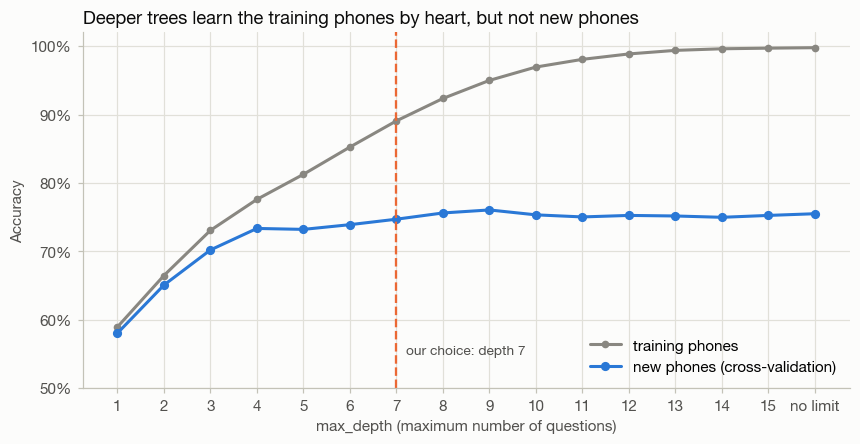

In [6]:
x = np.arange(len(depth_results))
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(x, depth_results["training accuracy"], color=MUTED, marker="o", markersize=4, label="training phones")
ax.plot(x, depth_results["CV accuracy"], color=BLUE, marker="o", markersize=5, label="new phones (cross-validation)")
chosen = list(depth_results.index).index(chosen_depth)
ax.axvline(chosen, color=ORANGE, linewidth=1.5, linestyle="--")
ax.annotate(f"our choice: depth {chosen_depth}", (chosen, 0.55), xytext=(6, 0), textcoords="offset points",
            fontsize=9, color=INK2)
ax.set_xticks(x, depth_results.index)
ax.set_ylim(0.5, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("max_depth (maximum number of questions)")
ax.set_ylabel("Accuracy")
ax.set_title("Deeper trees learn the training phones by heart, but not new phones")
ax.legend(loc="lower right")
save(fig, "t4_01_tree_depth")
plt.show()

- The **training accuracy** (grey) keeps rising with depth, up to 99.8% for an unlimited tree: a deep tree learns the training phones by heart.
- The **cross-validation accuracy** (blue, new phones) rises quickly until depth 4 (73.4%) and then stays almost flat. Its best value is at **depth 9 (76.1%)**; deeper trees don't help.
- The gap between the two lines is **overfitting**: at depth 9 the tree is right for 95.0% of the training phones but only for 76.1% of new phones.
- One standard error below the best score is 74.4%. The smallest depth that reaches it is **depth 7 (74.7%)**, so this is our choice for 4a: a tree with 63 leaves instead of 101, for practically the same accuracy on new phones.

### 4b · Different numbers of phones in a leaf
Now we let the tree grow as deep as it wants, and only change `min_samples_leaf`, the minimum number of training phones in each leaf. With 1, a leaf may describe a single phone; with 50, every answer must be backed by at least 50 phones.

In [7]:
leaf_sizes = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50, 75, 100]
leaf_results = pd.DataFrame([cv_scores(min_samples_leaf=n) for n in leaf_sizes], index=leaf_sizes)
leaf_results.index.name = "min_samples_leaf"

best_leaf = leaf_results["CV accuracy"].idxmax()
threshold = leaf_results.loc[best_leaf, "CV accuracy"] - leaf_results.loc[best_leaf, "CV standard error"]
chosen_leaf = leaf_results.index[leaf_results["CV accuracy"] >= threshold][-1]          # the largest leaf size that is good enough
print(f"Best CV accuracy: {best_leaf} phone(s) per leaf ({leaf_results.loc[best_leaf, 'CV accuracy']:.1%}) | "
      f"one standard error below it: {threshold:.1%} | the largest leaf size above that: {chosen_leaf} "
      f"({leaf_results.loc[chosen_leaf, 'CV accuracy']:.1%})")
leaf_results.style.format({"training accuracy": "{:.1%}", "CV accuracy": "{:.1%}", "CV standard error": "{:.1%}"})

Best CV accuracy: 5 phone(s) per leaf (75.6%) | one standard error below it: 73.9% | the largest leaf size above that: 12 (74.5%)


,training accuracy,CV accuracy,CV standard error,leaves
min_samples_leaf,,,,
1,99.8%,75.5%,1.8%,149
2,93.4%,75.1%,1.7%,120
3,90.5%,74.6%,1.7%,97
4,88.3%,75.1%,1.6%,89
5,86.8%,75.6%,1.8%,74
6,85.5%,75.4%,1.7%,67
8,83.5%,75.1%,1.4%,56
10,82.2%,75.2%,1.3%,46
12,80.7%,74.5%,1.6%,36


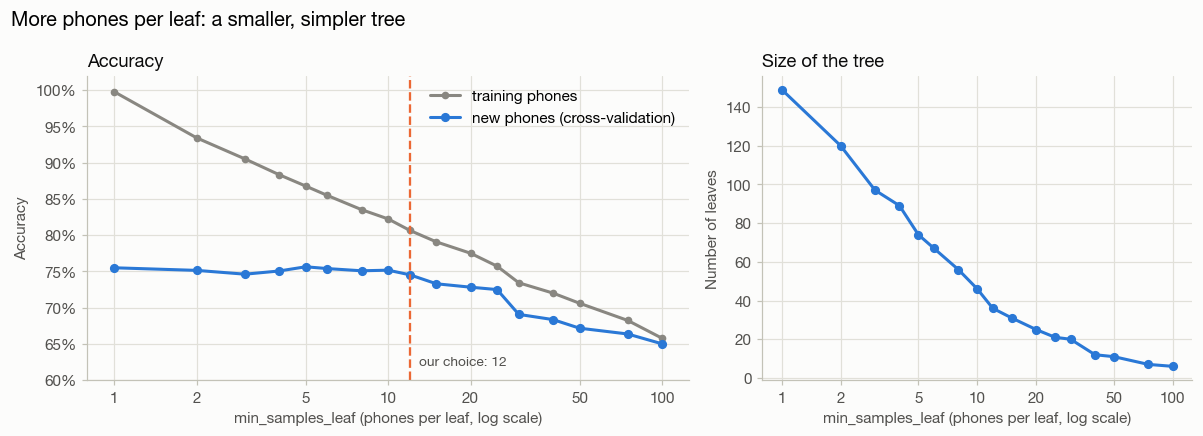

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axes[0]
ax.plot(leaf_sizes, leaf_results["training accuracy"], color=MUTED, marker="o", markersize=4, label="training phones")
ax.plot(leaf_sizes, leaf_results["CV accuracy"], color=BLUE, marker="o", markersize=5, label="new phones (cross-validation)")
ax.axvline(chosen_leaf, color=ORANGE, linewidth=1.5, linestyle="--")
ax.annotate(f"our choice: {chosen_leaf}", (chosen_leaf, 0.62), xytext=(6, 0), textcoords="offset points", fontsize=9, color=INK2)
ax.set_ylim(0.6, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy")
ax.legend(loc="upper right")

ax = axes[1]
ax.plot(leaf_sizes, leaf_results["leaves"], color=BLUE, marker="o", markersize=5)
ax.set_ylabel("Number of leaves")
ax.set_title("Size of the tree")
for ax in axes:
    ax.set_xscale("log")
    ax.set_xticks([1, 2, 5, 10, 20, 50, 100], ["1", "2", "5", "10", "20", "50", "100"])
    ax.minorticks_off()
    ax.set_xlabel("min_samples_leaf (phones per leaf, log scale)")
fig.suptitle("More phones per leaf: a smaller, simpler tree", x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "t4_02_leaf_size")
plt.show()

- With **1 phone per leaf**, the tree has 149 leaves and is right for 99.8% of the training phones, but only for 75.5% of new phones.
- Up to about 10 phones per leaf, the cross-validation accuracy stays around 75%, while the tree gets much smaller. The best value is with **5 phones per leaf (75.6%, 74 leaves)**.
- With 30 or more phones per leaf, the tree becomes too simple and the accuracy falls (69.1% with 30, 65.0% with 100).
- One standard error below the best score is 73.9%. The largest leaf size that reaches it is **12 phones per leaf (74.5%, 36 leaves)**, so this is our choice for 4b: half as many leaves as the best tree, and less overfitting (training accuracy 80.7% instead of 86.8%).

### 4c · Both settings together: our final tree
Depth and leaf size work together, so for our final tree we test every combination (12 depths × 10 leaf sizes = 120 trees, each with 25 cross-validation runs) and apply the same rule: the **smallest tree** (fewest leaves) whose score is within one standard error of the best.

In [9]:
grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    {"max_depth": list(range(2, 13)) + [None], "min_samples_leaf": [1, 2, 3, 5, 8, 10, 12, 15, 20, 30]},
                    cv=cv, scoring="accuracy").fit(X_train, y_train)
grid_results = pd.DataFrame(grid.cv_results_)
grid_results["max_depth"] = grid_results["param_max_depth"].map(lambda d: "no limit" if pd.isna(d) else str(int(d)))
grid_results["min_samples_leaf"] = grid_results["param_min_samples_leaf"].astype(int)
grid_results["leaves"] = [DecisionTreeClassifier(random_state=42, **p).fit(X_train, y_train).get_n_leaves()
                          for p in grid_results["params"]]

best = grid_results.loc[grid_results["mean_test_score"].idxmax()]
threshold = best["mean_test_score"] - best["std_test_score"] / np.sqrt(5)          # the standard error of a 5-fold CV
grid_results["depth_number"] = pd.to_numeric(grid_results["param_max_depth"], errors="coerce").fillna(99)          # "no limit" counts as the deepest
# The smallest tree (fewest leaves); if several trees are equally small, the most accurate, then the shallowest
good_enough = grid_results[grid_results["mean_test_score"] >= threshold].sort_values(
    ["leaves", "mean_test_score", "depth_number"], ascending=[True, False, True], kind="stable")
final = good_enough.iloc[0]
final_settings = final["params"]
print(f"Best combination: max_depth = {best['max_depth']}, min_samples_leaf = {best['min_samples_leaf']} "
      f"({best['mean_test_score']:.1%}, {best['leaves']} leaves)")
print(f"Our final tree:   max_depth = {final['max_depth']}, min_samples_leaf = {final['min_samples_leaf']} "
      f"({final['mean_test_score']:.1%}, {final['leaves']} leaves)")
good_enough[["max_depth", "min_samples_leaf", "mean_test_score", "leaves"]].head(6).rename(
    columns={"mean_test_score": "CV accuracy"}).style.format({"CV accuracy": "{:.1%}"}).hide(axis="index")

Best combination: max_depth = 9, min_samples_leaf = 1 (76.1%, 101 leaves)
Our final tree:   max_depth = 8, min_samples_leaf = 12 (74.5%, 36 leaves)


max_depth,min_samples_leaf,CV accuracy,leaves
8,12,74.5%,36
9,12,74.5%,36
10,12,74.5%,36
11,12,74.5%,36
12,12,74.5%,36
no limit,12,74.5%,36


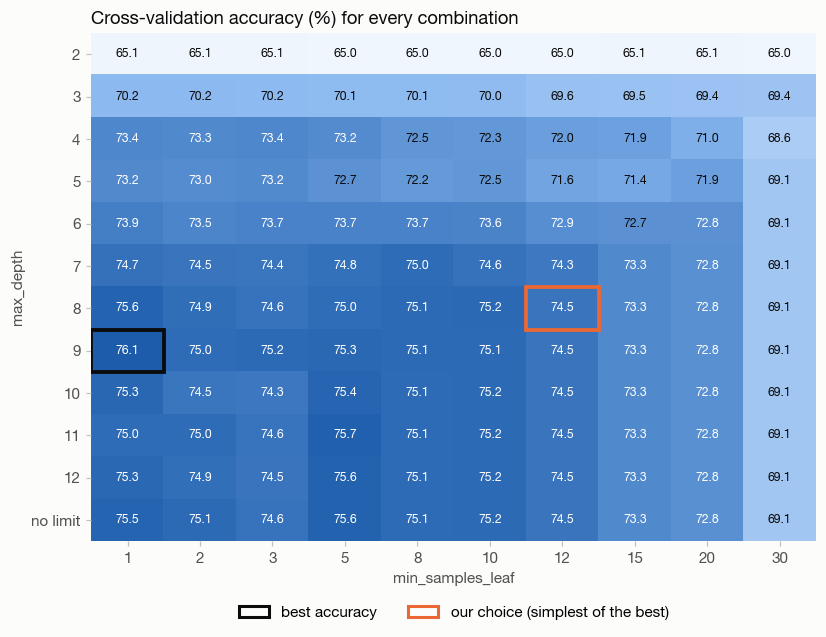

In [10]:
table = grid_results.pivot(index="max_depth", columns="min_samples_leaf", values="mean_test_score")
table = table.reindex([str(d) for d in range(2, 13)] + ["no limit"])
blues = LinearSegmentedColormap.from_list("blues", ["#f0f6fe", "#86b6ef", "#1c5cab"])

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.imshow(table.values, cmap=blues, aspect="auto")
for i in range(table.shape[0]):
    for j in range(table.shape[1]):
        v = table.values[i, j]
        ax.text(j, i, f"{v:.1%}".replace("%", ""), ha="center", va="center", fontsize=8,
                color="white" if v > table.values.min() + 0.7 * (table.values.max() - table.values.min()) else INK)
for row, col, color in [(best["max_depth"], best["min_samples_leaf"], INK), (final["max_depth"], final["min_samples_leaf"], ORANGE)]:
    i, j = list(table.index).index(row), list(table.columns).index(col)
    ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor=color, linewidth=2.5))
ax.set_xticks(range(table.shape[1]), table.columns)
ax.set_yticks(range(table.shape[0]), table.index)
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("max_depth")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(handles=[Patch(facecolor="none", edgecolor=INK, linewidth=2, label="best accuracy"),
                   Patch(facecolor="none", edgecolor=ORANGE, linewidth=2, label="our choice (simplest of the best)")],
          loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
ax.set_title("Cross-validation accuracy (%) for every combination")
save(fig, "t4_03_grid_search")
plt.show()

The best combination is depth 9 with 1 phone per leaf (76.1%), but that tree has 101 leaves. The smallest tree within one standard error of it has **max_depth = 8 and min_samples_leaf = 12: 36 leaves and 74.5%**. This is the same leaf size that we chose in 4b: with at least 12 phones per leaf, the tree stops growing at depth 8 by itself, so any depth limit from 8 up gives the same tree. **This is our final tree.**

## Part 5 · Evaluating our final tree
Now we train the final tree on the whole training set and use the **test set** for the first and only time. We compare it with two other models:
- a **baseline** that always answers the most common segment (Budget): every model must beat it,
- the **unlimited tree**, which grows until every leaf is pure: it shows what happens without our settings.

### 5.1 Classification quality on the test set
**Our metrics** (for 4 classes we compute precision, recall and F1 for each segment, and then take the simple average over the 4 segments, the *macro average*, so that the small Flagship segment counts as much as the big Budget segment):
- **Accuracy:** the share of phones we put in the right segment.
- **Precision:** of the phones we call "Flagship", the share that really are flagships (the same for each segment).
- **Recall:** of the real flagships, the share that we find.
- **F1-score:** the harmonic mean of precision and recall.
- **ROC-AUC (one-vs-rest):** for each segment, how well the tree ranks its phones above all other phones (0.5 = guessing, 1 = perfect), averaged over the 4 segments.

In [11]:
tree = DecisionTreeClassifier(random_state=42, **final_settings).fit(X_train, y_train)
full_tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
most_common = y_train.value_counts().idxmax()

def metrics(name, model, X_part, y_part):
    if model is None:          # the baseline: always the most common segment
        predicted, proba = np.full(len(y_part), most_common), np.tile(np.eye(4)[most_common], (len(y_part), 1))
    else:
        predicted, proba = model.predict(X_part), model.predict_proba(X_part)
    return {"model": name, "accuracy": accuracy_score(y_part, predicted),
            "precision (macro)": precision_score(y_part, predicted, average="macro", zero_division=0),
            "recall (macro)": recall_score(y_part, predicted, average="macro"),
            "F1 (macro)": f1_score(y_part, predicted, average="macro"),
            "ROC-AUC (one-vs-rest)": roc_auc_score(y_part, proba, multi_class="ovr", labels=[0, 1, 2, 3])}

results = pd.DataFrame([metrics("baseline: always Budget", None, X_test, y_test),
                        metrics("unlimited tree", full_tree, X_test, y_test),
                        metrics("our tree", tree, X_test, y_test),
                        metrics("our tree, on the training set", tree, X_train, y_train)]).set_index("model")
results.style.format("{:.3f}")

,accuracy,precision (macro),recall (macro),F1 (macro),ROC-AUC (one-vs-rest)
model,,,,,
baseline: always Budget,0.357,0.089,0.250,0.132,0.500
unlimited tree,0.780,0.811,0.800,0.803,0.859
our tree,0.797,0.817,0.791,0.802,0.916
"our tree, on the training set",0.825,0.818,0.805,0.810,0.963


In [12]:
predicted = tree.predict(X_test)
report = pd.DataFrame(classification_report(y_test, predicted, target_names=SEGMENTS, output_dict=True)).T
report.loc[SEGMENTS + ["macro avg"], ["precision", "recall", "f1-score", "support"]].style.format(
    {"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:.0f}"})

,precision,recall,f1-score,support
Budget,0.873,0.846,0.859,65
Mid-range,0.712,0.800,0.754,65
Premium,0.731,0.613,0.667,31
Flagship,0.950,0.905,0.927,21
macro avg,0.817,0.791,0.802,182


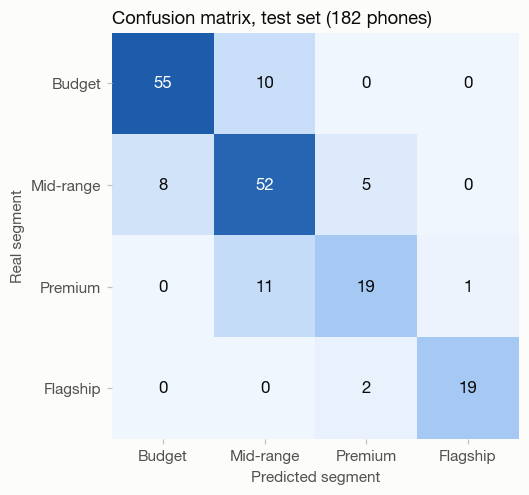

,predicted: Budget,predicted: Mid-range,predicted: Premium,predicted: Flagship
real: Budget,55,10,0,0
real: Mid-range,8,52,5,0
real: Premium,0,11,19,1
real: Flagship,0,0,2,19


In [13]:
cm = confusion_matrix(y_test, predicted, labels=[0, 1, 2, 3])
blues = LinearSegmentedColormap.from_list("blues", ["#f0f6fe", "#86b6ef", "#1c5cab"])
fig, ax = plt.subplots(figsize=(5.8, 4.8))
ax.imshow(cm, cmap=blues)
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11, fontweight="semibold" if i == j else "normal",
                color="white" if cm[i, j] > cm.max() * 0.6 else INK)
ax.set_xticks(range(4), SEGMENTS)
ax.set_yticks(range(4), SEGMENTS)
ax.set_xlabel("Predicted segment")
ax.set_ylabel("Real segment")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title(f"Confusion matrix, test set ({len(y_test)} phones)")
save(fig, "t4_05_confusion_matrix")
plt.show()
pd.DataFrame(cm, index=[f"real: {s}" for s in SEGMENTS], columns=[f"predicted: {s}" for s in SEGMENTS])

- **Our tree puts 79.7% of the test phones in the right segment**, more than twice as many as the baseline (35.7%). Its macro F1 is 0.80 and its ROC-AUC 0.92.
- **It is as good as the unlimited tree with a quarter of the leaves** (36 vs 149): accuracy 79.7% vs 78.0%, macro F1 0.80 for both. And its probabilities are better (ROC-AUC 0.92 vs 0.86): the leaves of the unlimited tree are pure, so it can only say 0% or 100%.
- **Flagship is the easiest segment** (F1 0.93): flagships stand out with fast processors, lots of RAM, foldable screens or the iPhone's 12 MP front camera. **Premium is the hardest** (F1 0.67): it sits between Mid-range and Flagship, and the tree often calls a Premium phone Mid-range (11 of 31).
- **Every mistake is between neighbouring segments**: the tree never calls a Budget phone Premium, or a Flagship Mid-range. When it is wrong, it is only one segment off.

### 5.2 Model characteristics
How big is our tree, how much did it overfit, and which specs does it use?

In [14]:
used = (tree.feature_importances_ > 0).sum()
characteristics = pd.DataFrame({
    "our tree": [tree.get_depth(), tree.get_n_leaves(), tree.tree_.node_count, used,
                 tree.score(X_train, y_train), tree.score(X_test, y_test)],
    "unlimited tree": [full_tree.get_depth(), full_tree.get_n_leaves(), full_tree.tree_.node_count,
                       (full_tree.feature_importances_ > 0).sum(), full_tree.score(X_train, y_train), full_tree.score(X_test, y_test)],
}, index=["depth", "leaves", "nodes (questions + leaves)", "features used (of 27)", "training accuracy", "test accuracy"])
characteristics.style.format("{:.0f}").format("{:.1%}", subset=pd.IndexSlice[["training accuracy", "test accuracy"], :])

,our tree,unlimited tree
depth,8,14
leaves,36,149
nodes (questions + leaves),71,297
features used (of 27),15,22
training accuracy,82.5%,99.7%
test accuracy,79.7%,78.0%


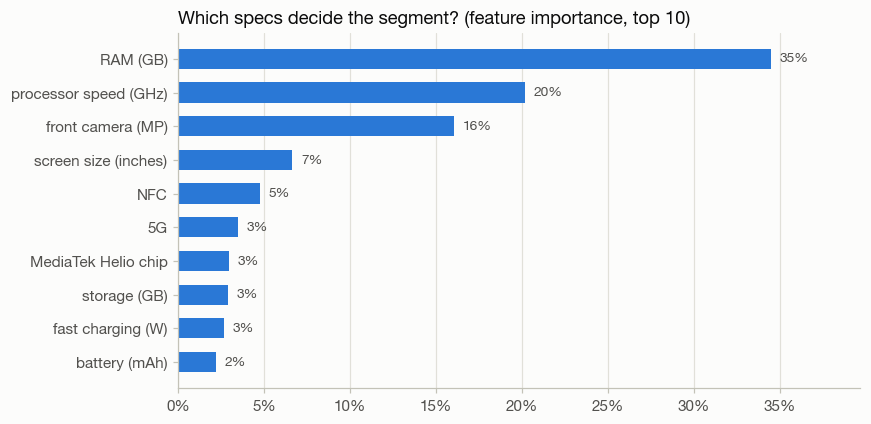

The top 2 features together: 54.7% | features not used at all: 12


,importance
RAM (GB),34.5%
processor speed (GHz),20.2%
front camera (MP),16.1%
screen size (inches),6.6%
NFC,4.8%
5G,3.5%
MediaTek Helio chip,3.0%
storage (GB),2.9%
fast charging (W),2.7%
battery (mAh),2.2%


In [15]:
importance = pd.Series(tree.feature_importances_, index=[NAMES[f] for f in features]).sort_values(ascending=False)
top = importance.head(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.barh(top.index, top.values, height=0.6, color=BLUE)
for yy, v in enumerate(top.values):
    ax.text(v + 0.005, yy, f"{v:.0%}", va="center", fontsize=9, color=INK2)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlim(0, top.max() * 1.15)
ax.grid(axis="y", visible=False)
ax.set_title("Which specs decide the segment? (feature importance, top 10)")
save(fig, "t4_06_feature_importance")
plt.show()
print(f"The top 2 features together: {importance.iloc[:2].sum():.1%} | features not used at all: {(importance == 0).sum()}")
importance.head(10).to_frame("importance").style.format("{:.1%}")

- **Our tree** has a depth of 8, 36 leaves and 71 nodes (35 questions and 36 leaves). It uses only 15 of the 27 features.
- **Overfitting:** our tree is right for 82.5% of the training phones and 79.7% of the test phones, a gap of only 2.8 points. The unlimited tree has a gap of 21.7 points (99.7% vs 78.0%): it learned the training phones by heart.
- **RAM (34.5%) and processor speed (20.2%)** make up 54.7% of the tree's decisions: the same two specs that drive the price in our linear regression in Task 3.
- The **front camera** is third (16.1%). The tree uses it to separate phones with similar RAM and processors, and a 12 MP front camera is typical of iPhones (see rule #7 in Part 6).
- 12 of the 27 features are not used at all.

### 5.3 Our tree
The whole tree is too big for one picture, so we show its **first three levels**: these are the most important questions. Each box shows the question, the number of training phones that reach it, how they are spread over the four segments (`value`), and the segment the tree would predict there. The colour shows that segment (light = Budget, dark = Flagship). For yes/no features, "≤ 0.5" means "No".

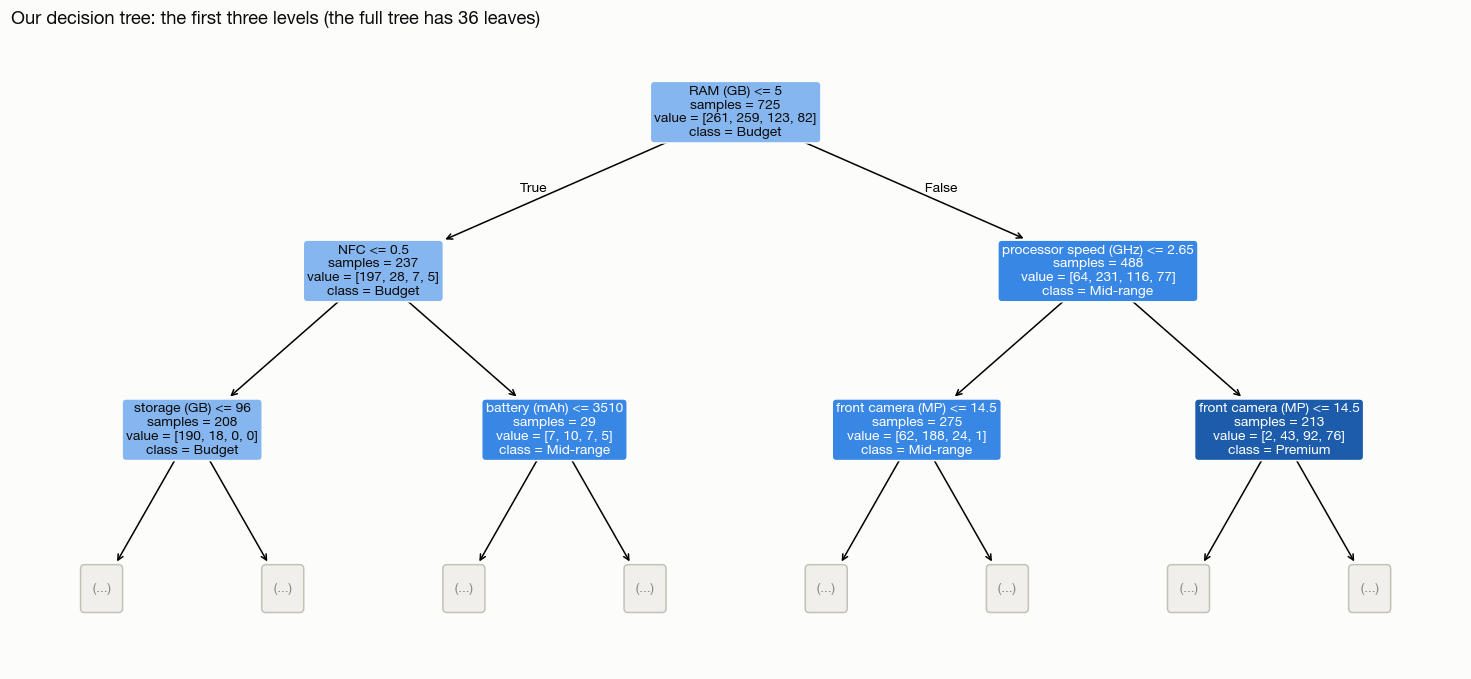

In [16]:
fig, ax = plt.subplots(figsize=(17, 7.5))
boxes = plot_tree(tree, max_depth=2, feature_names=[NAMES[f] for f in features], class_names=SEGMENTS,
                  filled=True, impurity=False, rounded=True, fontsize=9, ax=ax)
for box in boxes:          # we colour each box by its predicted segment, with our colours
    text = box.get_text()
    box.set_text(re.sub(r"(\d+)\.0\b", r"\1", text))          # 62.0 -> 62
    if "(...)" in text:          # the cut branches: a light box
        box.get_bbox_patch().set_facecolor("#f0efec")
        box.get_bbox_patch().set_edgecolor(AXIS)
        box.set_color(MUTED)
    if "class = " in text:
        segment = SEGMENTS.index(text.split("class = ")[1].strip())
        box.get_bbox_patch().set_facecolor(SEGMENT_COLORS[segment])
        box.get_bbox_patch().set_edgecolor(SURFACE)
        box.set_color(INK if segment == 0 else "white")
ax.set_title(f"Our decision tree: the first three levels (the full tree has {tree.get_n_leaves()} leaves)")
save(fig, "t4_04_decision_tree")
plt.show()

- **The first question is about RAM.** Phones with at most 4 GB of RAM (RAM ≤ 5 GB) go left: 197 of these 237 training phones are Budget phones.
- **On the left**, the tree then asks about NFC: phones without NFC and with at most 64 GB of storage (storage ≤ 96 GB) are almost all Budget phones (190 of 208).
- **On the right** (more RAM), the tree asks about the processor: up to 2.65 GHz, most phones are Mid-range (188 of 275); above it, most are Premium or Flagship (92 + 76 of 213).
- So the tree reads like a buyer's checklist: **first RAM, then NFC or the processor, then the details**.

The full tree as text (each line is one question; `class` is the predicted segment, 0 = Budget, 1 = Mid-range, 2 = Premium, 3 = Flagship):

In [17]:
print(export_text(tree, feature_names=[NAMES[f] for f in features], decimals=2))

|--- RAM (GB) <= 5.00
|   |--- NFC <= 0.50
|   |   |--- storage (GB) <= 96.00
|   |   |   |--- screen size (inches) <= 6.21
|   |   |   |   |--- class: 0
|   |   |   |--- screen size (inches) >  6.21
|   |   |   |   |--- main camera (MP) <= 49.00
|   |   |   |   |   |--- refresh rate (Hz) <= 75.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- refresh rate (Hz) >  75.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- main camera (MP) >  49.00
|   |   |   |   |   |--- processor speed (GHz) <= 2.25
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- processor speed (GHz) >  2.25
|   |   |   |   |   |   |--- class: 0
|   |   |--- storage (GB) >  96.00
|   |   |   |--- front camera (MP) <= 10.50
|   |   |   |   |--- class: 0
|   |   |   |--- front camera (MP) >  10.50
|   |   |   |   |--- class: 0
|   |--- NFC >  0.50
|   |   |--- battery (mAh) <= 3510.00
|   |   |   |--- class: 2
|   |   |--- battery (mAh) >  3510.00
|   |   |   |--- class: 1
|--- RAM

### 5.4 How stable is our result?
Our test set is only one random fifth of the data. To see how much the result depends on this luck, we repeat the split 20 times with different random seeds, train a tree with our final settings each time, and test it.

In [18]:
accuracies = []
for seed in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    accuracies.append(DecisionTreeClassifier(random_state=42, **final_settings).fit(X_tr, y_tr).score(X_te, y_te))
accuracies = pd.Series(accuracies)
print(f"Test accuracy over 20 random splits: mean {accuracies.mean():.1%}, from {accuracies.min():.1%} to {accuracies.max():.1%} "
      f"(standard deviation {accuracies.std():.1%})")

Test accuracy over 20 random splits: mean 76.3%, from 69.8% to 84.1% (standard deviation 3.8%)


Depending on which phones land in the test set, the accuracy of the same tree settings goes from 69.8% to 84.1%, with a mean of **76.3%**. So our 79.7% is a bit above average. The honest summary is: **our tree puts about 3 out of 4 phones (76%) in the right segment**, give or take 4 points. This also agrees with the cross-validation estimate from Part 4 (74.5%).

## Part 6 · Optional: decision rules from our tree
Every path from the top of the tree to a leaf is an **IF … THEN** rule: IF all the answers on the path are true, THEN the phone is in the leaf's segment. So our tree gives one rule per leaf. We make the rules simpler and turn them into a rule-based classifier in four steps (the idea of the classic C4.5rules method):

1. **Read the rules:** one rule per leaf. If a path asks about the same feature twice, we keep only the stricter condition.
2. **Simplify each rule:** we try to drop each condition. If the rule stays at least as accurate on the training phones, the condition wasn't needed, and we drop it. To measure accuracy we use the *Laplace estimate*, (correct + 1) / (covered + 4), which doesn't trust rules that cover very few phones.
3. **Order the rules and remove the weak ones:** we sort the rules from the most to the least accurate. A rule must cover at least 5 training phones that no earlier rule covers; otherwise we drop it.
4. **Classify:** for a phone we go through the rules in order, and the **first rule that matches** decides. If no rule matches, a **default rule** gives the most common segment of the training phones that no rule covers.

In [19]:
def tree_to_rules(model):
    # Step 1: one rule per leaf, made of the conditions on the path from the top to the leaf
    t, rules = model.tree_, []
    def walk(node, conditions):
        if t.children_left[node] == -1:          # a leaf
            rules.append(conditions)
            return
        feature, threshold = features[t.feature[node]], t.threshold[node]
        walk(t.children_left[node], conditions + [(feature, "<=", threshold)])
        walk(t.children_right[node], conditions + [(feature, ">", threshold)])
    walk(0, [])
    return [keep_strictest(conditions) for conditions in rules]

def keep_strictest(conditions):
    # If the path asks about the same feature twice in the same direction, the stricter condition is enough
    strictest = {}
    for feature, op, threshold in conditions:
        key = (feature, op)
        if key not in strictest or (threshold < strictest[key] if op == "<=" else threshold > strictest[key]):
            strictest[key] = threshold
    return [(feature, op, threshold) for (feature, op), threshold in strictest.items()]

def matches(conditions, data):
    # Which phones meet all the conditions of a rule?
    mask = np.ones(len(data), dtype=bool)
    for feature, op, threshold in conditions:
        mask &= (data[feature].values <= threshold) if op == "<=" else (data[feature].values > threshold)
    return mask

def quality(conditions, label, data, target):
    # How many training phones a rule covers, how many it gets right, and its Laplace accuracy
    covered = matches(conditions, data)
    correct = int((target.values[covered] == label).sum())
    return int(covered.sum()), correct, (correct + 1) / (covered.sum() + 4)

def simplify(conditions, label):
    # Step 2: drop conditions as long as the rule doesn't get less accurate
    covered, correct, laplace = quality(conditions, label, X_train, y_train)
    dropped = True
    while dropped and conditions:
        dropped = False
        for condition in conditions:
            shorter = [c for c in conditions if c != condition]
            covered2, correct2, laplace2 = quality(shorter, label, X_train, y_train)
            if laplace2 >= laplace:
                conditions, covered, correct, laplace, dropped = shorter, covered2, correct2, laplace2, True
                break
    return conditions, covered, correct, laplace

In [20]:
candidates = []
for conditions in tree_to_rules(tree):
    label = int(y_train[matches(conditions, X_train)].value_counts().idxmax())          # the leaf's segment
    conditions, covered, correct, laplace = simplify(conditions, label)
    candidates.append({"conditions": conditions, "segment": label, "covered": covered, "correct": correct, "laplace": laplace})

# Step 3: order by accuracy; a rule must cover at least 5 training phones that no earlier rule covers
rules, already = [], np.zeros(len(X_train), dtype=bool)
for rule in sorted(candidates, key=lambda r: (-r["laplace"], -r["covered"])):
    new = matches(rule["conditions"], X_train) & ~already
    if new.sum() >= 5:
        rules.append(rule)
        already |= new
default_segment = int(y_train[~already].value_counts().idxmax()) if (~already).any() else int(most_common)

def predict_with_rules(data):
    # Step 4: the first matching rule decides; otherwise the default rule
    predicted = np.full(len(data), default_segment)
    which_rule = np.full(len(data), -1)
    for number, rule in enumerate(rules):
        hit = matches(rule["conditions"], data) & (which_rule == -1)
        predicted[hit], which_rule[hit] = rule["segment"], number
    return predicted, which_rule

print(f"{tree.get_n_leaves()} rules from the leaves -> {len(rules)} rules after simplifying, plus a default rule "
      f"({SEGMENTS[default_segment]}) | training phones covered by a rule: {already.mean():.1%}")

36 rules from the leaves -> 30 rules after simplifying, plus a default rule (Mid-range) | training phones covered by a rule: 99.0%


### 6.1 Our rules

In [21]:
BINARY = {"has_5g": ("5G", "no 5G"), "has_nfc": ("NFC", "no NFC"), "has_ir_blaster": ("IR blaster", "no IR blaster"),
          "extended_memory_available": ("memory-card slot", "no memory-card slot"),
          "os_ios": ("iPhone", "not an iPhone"), "is_foldable": ("foldable", "not foldable")}
UNITS = {"processor_speed": ("processor speed", "GHz"), "ram_capacity": ("RAM", "GB"), "internal_memory": ("storage", "GB"),
         "battery_capacity": ("battery", "mAh"), "fast_charging": ("fast charging", "W"), "screen_size": ("screen", "inches"),
         "refresh_rate": ("refresh rate", "Hz"), "primary_camera_rear": ("main camera", "MP"),
         "primary_camera_front": ("front camera", "MP"), "num_rear_cameras": ("rear cameras", ""), "ppi": ("pixel density", "ppi")}

def number(v):
    return f"{v:,.0f}" if abs(v - round(v)) < 1e-9 else f"{v:,.2f}".rstrip("0").rstrip(".")

def rule_text(conditions):
    # Turns the conditions into readable English, e.g. "RAM ≤ 5 GB and no NFC"
    parts, bounds = [], {}
    for feature, op, threshold in conditions:
        if feature in BINARY or feature.startswith("chip_"):
            yes, no = BINARY.get(feature, (NAMES[feature], f"not a {NAMES[feature]}"))
            parts.append(yes if op == ">" else no)
        else:
            bounds.setdefault(feature, {})[op] = threshold
    for feature, b in bounds.items():
        name, unit = UNITS[feature]
        unit = f" {unit}" if unit else ""
        if "<=" in b and ">" in b:
            parts.append(f"{number(b['>'])} < {name} ≤ {number(b['<='])}{unit}")
        elif "<=" in b:
            parts.append(f"{name} ≤ {number(b['<='])}{unit}")
        else:
            parts.append(f"{name} > {number(b['>'])}{unit}")
    return " and ".join(sorted(parts, key=lambda p: (p.startswith(("no ", "not ")), p))) or "(always)"

rule_table = pd.DataFrame([{"#": i + 1, "IF": rule_text(r["conditions"]), "THEN": SEGMENTS[r["segment"]],
                            "training phones covered": r["covered"], "accuracy on them": r["correct"] / r["covered"]}
                           for i, r in enumerate(rules)])
rule_table.loc[len(rule_table)] = [len(rules) + 1, "no rule above matches", SEGMENTS[default_segment],
                                   int((~already).sum()), np.nan]
rule_table.style.format({"accuracy on them": "{:.0%}"}, na_rep="").format(escape="html", subset=["IF"]).hide(axis="index")

#,IF,THEN,training phones covered,accuracy on them
1,RAM ≤ 5 GB and main camera ≤ 49 MP and refresh rate ≤ 75 Hz and screen > 6.21 inches and storage ≤ 96 GB and no NFC,Budget,91,100%
2,14.5 < front camera ≤ 22 MP and RAM > 7 GB and processor speed ≤ 2.65 GHz and no NFC,Mid-range,46,100%
3,RAM ≤ 5 GB and processor speed ≤ 2.25 GHz and storage ≤ 96 GB,Budget,119,95%
4,RAM ≤ 5 GB and front camera ≤ 10.5 MP and no NFC,Budget,155,94%
5,MediaTek Helio chip and front camera ≤ 14.5 MP,Budget,102,95%
6,fast charging ≤ 19 W and front camera ≤ 14.5 MP and pixel density ≤ 399.5 ppi and processor speed ≤ 2.65 GHz,Budget,161,93%
7,11.55 < front camera ≤ 14.5 MP and RAM > 5 GB and processor speed > 2.65 GHz,Flagship,28,100%
8,storage ≤ 96 GB and no NFC,Budget,188,91%
9,RAM ≤ 5 GB and no NFC,Budget,208,91%
10,RAM ≤ 5 GB and storage ≤ 96 GB,Budget,181,91%


In [22]:
# Which phones are behind the Flagship rules? We count the iPhones among the training phones each rule covers
is_iphone = df.loc[X_train.index, "brand_name"].eq("apple").values
display(pd.DataFrame([{"rule": f"#{i + 1}", "IF": rule_text(r["conditions"]), "training phones covered": r["covered"],
                       "of them iPhones": int(is_iphone[matches(r["conditions"], X_train)].sum())}
                      for i, r in enumerate(rules) if r["segment"] == 3]).style.format(escape="html", subset=["IF"]).hide(axis="index"))
iphones = df[df["brand_name"] == "apple"]
print(f"iPhones with a 12 MP front camera: {(iphones['primary_camera_front'] == 12).sum()} of {len(iphones)}")

rule,IF,training phones covered,of them iPhones
#7,11.55 < front camera ≤ 14.5 MP and RAM > 5 GB and processor speed > 2.65 GHz,28,18
#13,foldable,17,0
#25,processor speed > 2.65 GHz and screen > 6.79 inches,31,0
#26,front camera ≤ 11.55 MP and processor speed > 2.65 GHz and screen > 6.45 inches,20,0


iPhones with a 12 MP front camera: 37 of 40


Our tree's 36 leaves became **30 rules plus a default rule**. Some rules are short and easy to read, and they match what we found in Tasks 2 and 3:
- **#13: every foldable phone is a Flagship** (17 of 17 training phones).
- **#9: 4 GB of RAM or less (RAM ≤ 5 GB) and no NFC → Budget** (91% of 208 phones).
- **#22: more than 4 GB of RAM, fast charging above 19 W and a processor up to 2.65 GHz → Mid-range** (76% of 206 phones).
- **#7: a fast processor (> 2.65 GHz), more than 4 GB of RAM and a 12–14 MP front camera → Flagship** (28 of 28). 18 of these 28 phones are iPhones, because 37 of our 40 iPhones have a 12 MP front camera: **the tree found the iPhones through their selfie camera**, not through the "iPhone" feature.

Other rules are longer and less intuitive, with thresholds on pixel density or screen size. These are the small corrections the tree needs to get the last phones right.

### 6.2 Classification with the rules, and rules vs tree
We classify the test phones with our rules and compare them with the tree they came from.

In [23]:
rule_predictions, fired = predict_with_rules(X_test)
tree_predictions = tree.predict(X_test)
avg_conditions_tree = np.mean([len(c) for c in tree_to_rules(tree)])
avg_conditions_rules = np.mean([len(r["conditions"]) for r in rules])

comparison = pd.DataFrame({
    "decision tree": [accuracy_score(y_test, tree_predictions), f1_score(y_test, tree_predictions, average="macro"),
                      tree.get_n_leaves(), avg_conditions_tree],
    "decision rules": [accuracy_score(y_test, rule_predictions), f1_score(y_test, rule_predictions, average="macro"),
                       len(rules) + 1, avg_conditions_rules],
}, index=["test accuracy", "test F1 (macro)", "number of leaves / rules (with the default rule)", "conditions per leaf / rule"])
display(comparison.style.format("{:.3f}").format("{:.0f}", subset=pd.IndexSlice[["number of leaves / rules (with the default rule)"], :])
        .format("{:.1f}", subset=pd.IndexSlice[["conditions per leaf / rule"], :]))
print(f"The two classifiers give the same answer for {np.mean(tree_predictions == rule_predictions):.1%} of the test phones "
      f"({(tree_predictions != rule_predictions).sum()} of {len(y_test)} differ) | test phones decided by the default rule: "
      f"{(fired == -1).sum()}")

,decision tree,decision rules
test accuracy,0.797,0.791
test F1 (macro),0.802,0.778
number of leaves / rules (with the default rule),36,31
conditions per leaf / rule,5.5,3.6


The two classifiers give the same answer for 91.8% of the test phones (15 of 182 differ) | test phones decided by the default rule: 2


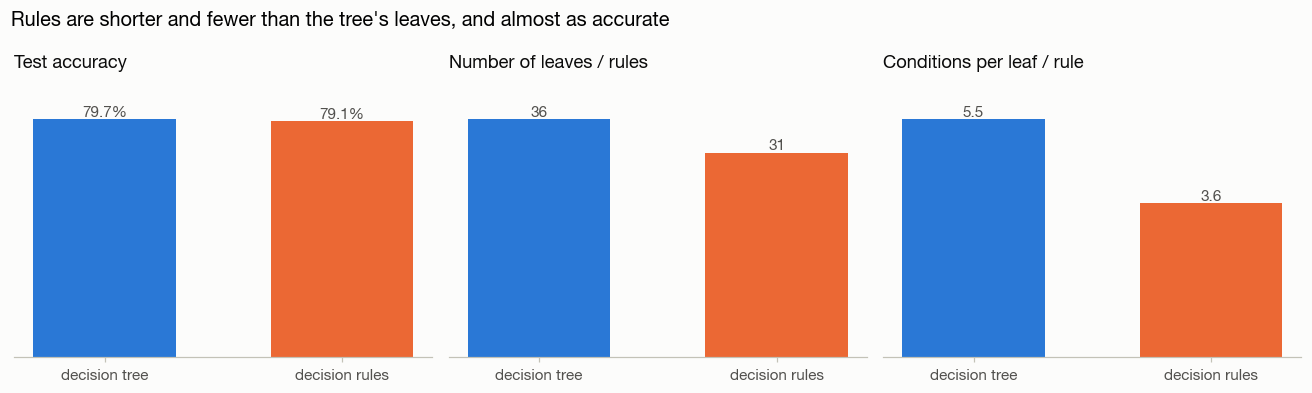

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
panels = [("Test accuracy", comparison.loc["test accuracy"], "{:.1%}"),
          ("Number of leaves / rules", comparison.loc["number of leaves / rules (with the default rule)"], "{:.0f}"),
          ("Conditions per leaf / rule", comparison.loc["conditions per leaf / rule"], "{:.1f}")]
for ax, (title, values, fmt) in zip(axes, panels):
    bars = ax.bar(["decision tree", "decision rules"], values.values, color=[BLUE, ORANGE], width=0.6)
    for bar, v in zip(bars, values.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v, fmt.format(v), ha="center", va="bottom", fontsize=10, color=INK2)
    ax.set_title(title)
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.grid(False)
    ax.set_ylim(0, values.max() * 1.18)
fig.suptitle("Rules are shorter and fewer than the tree's leaves, and almost as accurate",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
fig.tight_layout()
save(fig, "t4_07_tree_vs_rules")
plt.show()

- **Accuracy:** the rules are almost as good as the tree: 79.1% vs 79.7% on the test set (macro F1 0.78 vs 0.80).
- **Agreement:** both give the same answer for 91.8% of the test phones (15 of 182 differ). The default rule decided only 2 test phones.
- **Simplicity:** the rules are fewer (31 with the default rule, against 36 leaves) and shorter (3.6 conditions instead of 5.5), and each rule can be read on its own.

So the **rule-based classifier** is easier to read and to explain, and it costs us less than one percentage point of accuracy. The tree is a bit more accurate, and it shows how the questions depend on each other.

### 6.3 Classifying new phones
Finally, we describe four new phones and let both classifiers decide their segment. For the rules, we also show which rule decided.

In [25]:
def new_phone(chip, **specs):
    # We start from a typical phone (the median of the training set), set its chip family, and change the specs we give
    phone = X_train.median()
    phone[[f for f in features if f.startswith("chip_")]] = 0
    phone[f"chip_{chip}"] = 1
    for feature, value in specs.items():
        phone[feature] = value
    return phone

new_phones = pd.DataFrame({
    "Budget-style phone (Helio, 4 GB, 64 GB, no 5G)": new_phone("helio", processor_speed=2.0, ram_capacity=4, internal_memory=64,
        has_5g=0, has_nfc=0, refresh_rate=60, fast_charging=10, primary_camera_front=5),
    "Mid-range 5G phone (Dimensity, 8 GB, 128 GB)": new_phone("dimensity", processor_speed=2.4, ram_capacity=8, internal_memory=128,
        has_5g=1, has_nfc=0, refresh_rate=120, fast_charging=33, primary_camera_front=16),
    "Premium phone (Snapdragon, 8 GB, 256 GB, NFC)": new_phone("snapdragon", processor_speed=2.9, ram_capacity=8, internal_memory=256,
        has_5g=1, has_nfc=1, refresh_rate=120, fast_charging=67, primary_camera_front=32),
    "iPhone-style phone (Bionic, 6 GB, 128 GB)": new_phone("bionic", processor_speed=3.2, ram_capacity=6, internal_memory=128,
        has_5g=1, has_nfc=1, os_ios=1, refresh_rate=60, fast_charging=20, primary_camera_front=12, battery_capacity=3300,
        extended_memory_available=0, screen_size=6.1, ppi=460),
}).T[features]

tree_answer = tree.predict(new_phones)
tree_sure = tree.predict_proba(new_phones).max(axis=1)
rule_answer, rule_number = predict_with_rules(new_phones)
pd.DataFrame({"decision tree": [SEGMENTS[s] for s in tree_answer],
              "share of the leaf's phones in that segment": tree_sure,
              "decision rules": [SEGMENTS[s] for s in rule_answer],
              "rule that decided": [f"#{n + 1}: IF {rule_text(rules[n]['conditions'])}" if n >= 0 else "default rule"
                                    for n in rule_number]}, index=new_phones.index).style.format(
    {"share of the leaf's phones in that segment": "{:.0%}"}).format(escape="html", subset=["rule that decided"])

,decision tree,share of the leaf's phones in that segment,decision rules,rule that decided
"Budget-style phone (Helio, 4 GB, 64 GB, no 5G)",Budget,100%,Budget,#3: IF RAM ≤ 5 GB and processor speed ≤ 2.25 GHz and storage ≤ 96 GB
"Mid-range 5G phone (Dimensity, 8 GB, 128 GB)",Mid-range,100%,Mid-range,#2: IF 14.5 < front camera ≤ 22 MP and RAM > 7 GB and processor speed ≤ 2.65 GHz and no NFC
"Premium phone (Snapdragon, 8 GB, 256 GB, NFC)",Premium,75%,Premium,#21: IF front camera > 14.5 MP and pixel density ≤ 425 ppi and processor speed > 2.65 GHz and screen ≤ 6.79 inches and storage > 192 GB
"iPhone-style phone (Bionic, 6 GB, 128 GB)",Flagship,100%,Flagship,#7: IF 11.55 < front camera ≤ 14.5 MP and RAM > 5 GB and processor speed > 2.65 GHz


Both classifiers put all four phones in the segment we would expect, and we can say **why**: the iPhone-style phone is a Flagship because of rule #7 (fast processor, more than 4 GB of RAM, 12 MP front camera), and the budget-style phone is a Budget phone because of rule #3 (RAM ≤ 5 GB, processor ≤ 2.25 GHz, storage ≤ 96 GB). For the premium phone the tree is less sure: only 75% of the training phones in its leaf are Premium phones.

This is the big advantage of trees and rules over models like logistic regression: **every decision can be explained in plain words**.

# Summary of Task 4

| Task | What we did and found |
|---|---|
| 1. Dataset | 907 phones in 4 price segments (Budget 36%, Mid-range 36%, Premium 17%, Flagship 11%) |
| 2. Data preparation | 27 specs as features; no price and no rating (both contain the price); no scaling needed |
| 3. Splitting | stratified 80/20 split (725 / 182 phones) and 5 × repeated 5-fold cross-validation on the training set |
| 4a. Tree depth | best: depth 9 (76.1%); our choice: depth 7 (74.7%), the simplest within one standard error |
| 4b. Phones per leaf | best: 5 (75.6%); our choice: 12 (74.5%, 36 leaves) |
| Final tree | max_depth = 8, min_samples_leaf = 12: 36 leaves, 15 of 27 features used |
| 5. Test set | accuracy 79.7% (baseline 35.7%), macro F1 0.80, ROC-AUC 0.92; all mistakes between neighbouring segments; 76% on average over 20 random splits |
| 6. Decision rules | 30 rules + a default rule: 79.1% accuracy (tree: 79.7%), 3.6 conditions per rule (tree: 5.5) |

**Our answer:** yes, a decision tree can tell a phone's price segment from its specs alone for about 3 out of 4 phones, and when it is wrong, it is only one segment off. The deciding specs are **RAM and processor speed**, the same specs that drove the price in Task 3. The rules put this into plain words: 4 GB of RAM without NFC means a Budget phone, a foldable screen means a Flagship.

**What we keep in mind**
- **Trees are unstable:** with another random split, the tree and its rules would look somewhat different, and the test accuracy moves between about 70% and 84%.
- **The specs don't explain everything:** about 1 in 4 phones lands in the wrong segment, because the price also depends on things our data doesn't have, such as the brand's image, the design or the release date.